# Working with complicated dataset

Your name: Andy Liu

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [ ]:
### Your code here . . .
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
blast_results = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

In [ ]:
import urllib.request

### Read the first few lines
with urllib.request.urlopen(blast_results) as response:
    for i in range(15):
        line = response.readline().decode('utf-8').strip()
        print(f"{i + 1}: {line}")

1: # blastp,,,,,,,,,,,,,,,
2: # Iteration: 0,,,,,,,,,,,,,,,
3: # Query: YP_220550.1 NADH dehydrogenase subunit 1 (mitochondrion) [Mus musculus domesticus],,,,,,,,,,,,,,,
4: # RID: 9SW3UNUT015,,,,,,,,,,,,,,,
5: # Database: nr,,,,,,,,,,,,,,,
6: "# Fields: query acc.ver, subject acc.ver, % identity, alignment length, mismatches, gap opens, q. start, q. end, s. start, s. end, evalue, bit score, % positives, bonds, publications",,,,,,,,,,,,,,,
7: # 100 hits found,,,,,,,,,,,,,,,
8: YP_220550.1,NP_904328.1,100,318,0,0,1,318,1,318,0,629,100," 1,487 ",9,
9: YP_220550.1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100," 17,947 ",47,
10: YP_220550.1,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100," 12,106 ",13,
11: YP_220550.1,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69," 2,319 ",41,
12: YP_220550.1,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100," 18,964 ",3,
13: YP_220550.1,AEN03421.1,99.686,318,1,0,1,318,1,318,0,626,99.69," 12,444 ",39,
14: YP_220550.1,6G2J_H,100,317,0,0,2,318,2,318,0,62

In [ ]:
blast_result_columns = ["query acc.ver",
                        "subject acc.ver",
                        "% identity",
                        "alignment length",
                        "mismatches",
                        "gap opens",
                        "q. start",
                        "q. end",
                       "s. start",
                        "s. end",
                        "evalue",
                        "bit score",
                        "% positives",
                        "bonds",
                        "publications"]

blast = pd.read_csv(blast_results,
                    skiprows=7,
                    header=None,
                    names=blast_result_columns,
                    usecols=blast_result_columns,
                    thousands=','
                    )
blast.drop(columns="query acc.ver", inplace=True)
blast.set_index("subject acc.ver", inplace=True)
blast['publications'] = pd.to_numeric(blast['publications'], errors='coerce').astype('Int64')
blast.info()
blast.head(5)

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, NP_904328.1 to AGS12808.1
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   % identity        100 non-null    float64
 1   alignment length  100 non-null    int64  
 2   mismatches        100 non-null    int64  
 3   gap opens         100 non-null    int64  
 4   q. start          100 non-null    int64  
 5   q. end            100 non-null    int64  
 6   s. start          100 non-null    int64  
 7   s. end            100 non-null    int64  
 8   evalue            100 non-null    int64  
 9   bit score         100 non-null    int64  
 10  % positives       100 non-null    float64
 11  bonds             100 non-null    int64  
 12  publications      97 non-null     Int64  
dtypes: Int64(1), float64(2), int64(10)
memory usage: 11.0+ KB


,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3


### Question 2

---


What is the average number of publications?

In [ ]:
### Your code here . . .
blast['publications'].mean()

np.float64(26.989690721649485)

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [ ]:
### Your code here . . .
blast[blast['bonds'] > 15000]['bonds']

,bonds
subject acc.ver,
AGK29621.1,17947
AHG32084.1,18964
6G2J_H,15663
YP_002791042.1,15830
AGK29634.1,17381
0806162F,17499
YP_009112408.1,16861
YP_001876469.1,16274
YP_009092269.1,16170


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

Text(0.5, 1.0, 'Correlation between % Identity and % Positives')

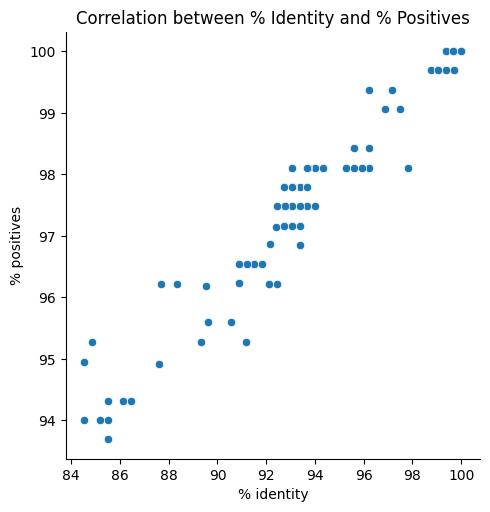

In [ ]:
### Your code here . . .
sns.relplot(data=blast,
            x='% identity',
            y='% positives')
plt.title("Correlation between % Identity and % Positives")

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [ ]:
### Your code here . . .
proteins = pd.read_csv("https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv")
proteins.drop(columns='Unnamed: 0', inplace=True)
proteins.rename(columns={'Protein': 'subject acc.ver', 'Source': 'Protein source'}, inplace=True)
proteins.set_index('subject acc.ver', inplace=True)
proteins.head()

blast = blast.merge(proteins, left_index=True, right_index=True, how='left')
blast['Protein source'] = blast['Protein source'].fillna('NA')
blast

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47,NA
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41,NA
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ABX45285.1,92.767,318,23,0,1,318,1,318,0,551,97.48,17348,6,NA
ASP44815.1,93.375,317,21,0,1,317,1,317,0,551,96.85,7105,19,NA
YP_009414156.1,84.543,317,49,0,1,317,1,317,0,551,94.01,18940,37,GenPept
